## EDA: 糖尿病予測チャレンジ
このノートブックでは、糖尿病予測チャレンジのデータを探索的に分析します。

In [3]:
import sys

sys.path.append("../utils")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from scipy.stats import skew
from scipy.special import boxcox1p
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings("ignore")

from utils import check_df

In [4]:
# データ読み込み
class Paths:
    p = "/Users/shirokoshikentaro/Downloads/Diabetes Prediction Challenge/Data"
    train = p + "/train.csv"
    test = p + "/test.csv"
    sample = p + "/sample_submission.csv"

In [5]:
train = pd.read_csv(Paths.train)
test = pd.read_csv(Paths.test)

# 元のデータのobject型の列を確認（reduce_mem_usage実行前）
print("元のデータのobject型の列:")
print(train.select_dtypes(include=["object"]).columns.tolist())

元のデータのobject型の列:
['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [6]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

In [7]:
train = reduce_mem_usage(train)

Memory usage of dataframe is 138.86 MB
Memory usage after optimization is: 26.70 MB
Decreased by 80.8%


In [8]:
check_df(train)

,Column,dtypes,NaN Count,Nunique,Unique Values
0,id,int32,0,700000,> 10 unique values
1,age,int8,0,71,> 10 unique values
2,alcohol_consumption_per_week,int8,0,9,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
3,physical_activity_minutes_per_week,int16,0,565,> 10 unique values
4,diet_score,float16,0,99,> 10 unique values
5,sleep_hours_per_day,float16,0,69,> 10 unique values
6,screen_time_hours_per_day,float16,0,151,> 10 unique values
7,bmi,float16,0,231,> 10 unique values
8,waist_to_hip_ratio,float16,0,36,> 10 unique values
9,systolic_bp,int16,0,71,> 10 unique values


In [9]:
print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

train shape: (700000, 26)
test shape: (300000, 25)


In [10]:
# 数値型の列を取得
num_features = train.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove("id")
num_features.remove("diagnosed_diabetes")
num_features


['age',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history']

In [11]:
# カテゴリカル変数を抽出（object型とcategory型の両方を含む）
# reduce_mem_usageでobject型がcategory型に変換されているため、両方を含める
cat_features = train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_features

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'smoking_status',
 'employment_status']

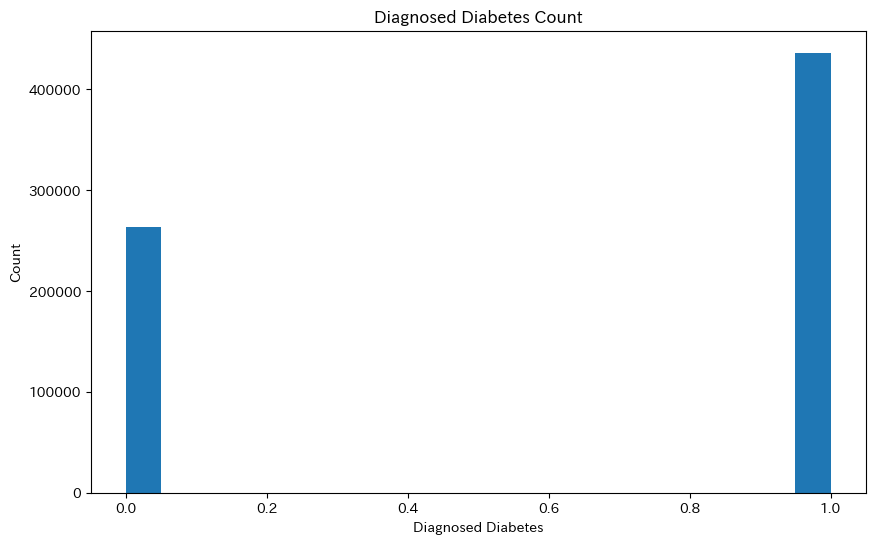

In [12]:
target_col = "diagnosed_diabetes"

plt.figure(figsize=(10, 6))
plt.title("Diagnosed Diabetes Count")
plt.hist(train[target_col],bins=20)
plt.xlabel("Diagnosed Diabetes")
plt.ylabel("Count")
plt.show()

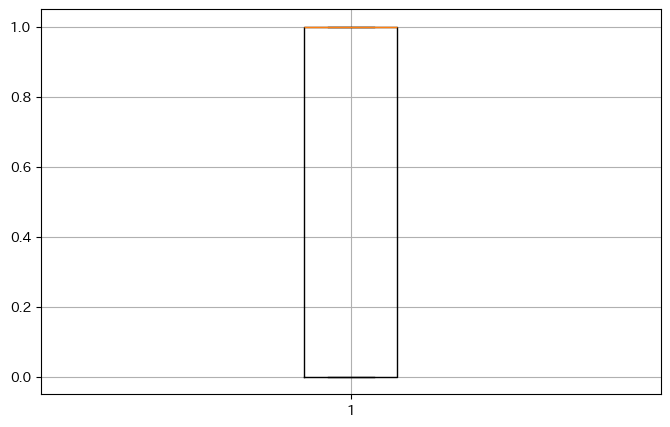

In [13]:
plt.figure(figsize=(8, 5))
plt.boxplot(train[target_col])
plt.grid()
plt.show()

In [14]:
correlation_with_target = (
    train[num_features + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

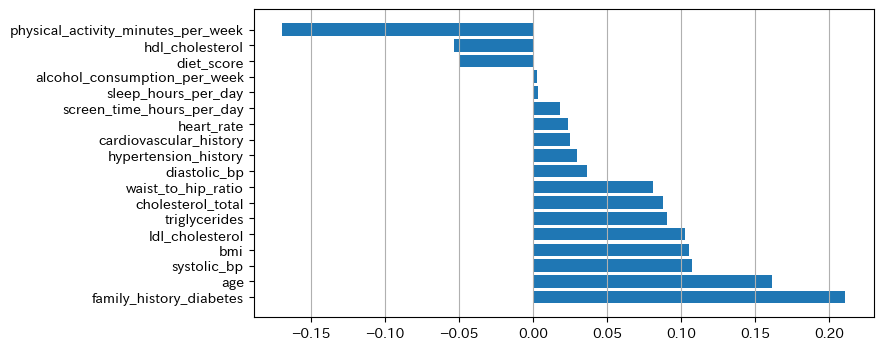

In [15]:
plt.figure(figsize=(8, 4))
plt.barh(range(len(correlation_with_target)), correlation_with_target.values)
plt.yticks(range(len(correlation_with_target)), correlation_with_target.index)
plt.grid(axis="x")
plt.show()

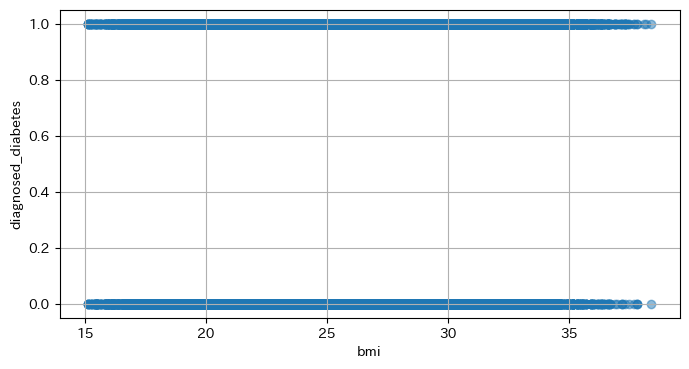

In [17]:
plt.figure(figsize=(8, 4))
plt.scatter(train["bmi"], train[target_col], alpha=0.5)
plt.xlabel("bmi")
plt.ylabel(target_col)
plt.grid()
plt.show()

In [ ]:
features = [
    "bmi",
    "waist_to_hip_ratio",
    "family_history_diabetes",
    "hypertension_history",
    "triglycerides",
    "hdl_cholesterol",
]
target = "diagnosed_diabetes"

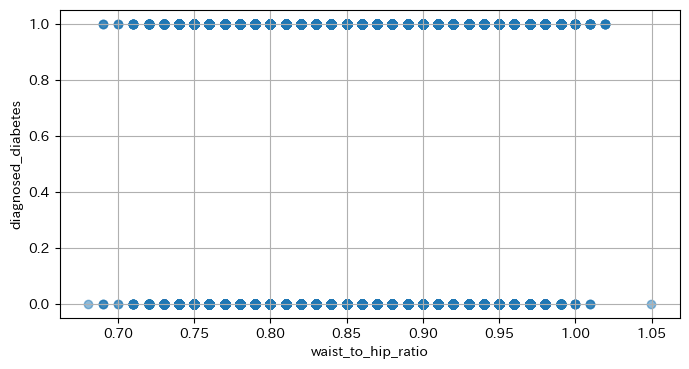

In [18]:
plt.figure(figsize=(8, 4))
plt.scatter(train["waist_to_hip_ratio"], train[target_col], alpha=0.5)
plt.xlabel("waist_to_hip_ratio")
plt.ylabel(target_col)
plt.grid()
plt.show()

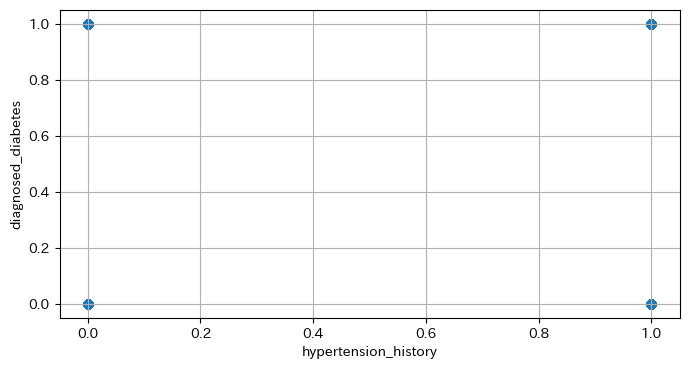

In [19]:
plt.figure(figsize=(8, 4))
plt.scatter(train["hypertension_history"], train[target_col], alpha=0.5)
plt.xlabel("hypertension_history")
plt.ylabel(target_col)
plt.grid()
plt.show()

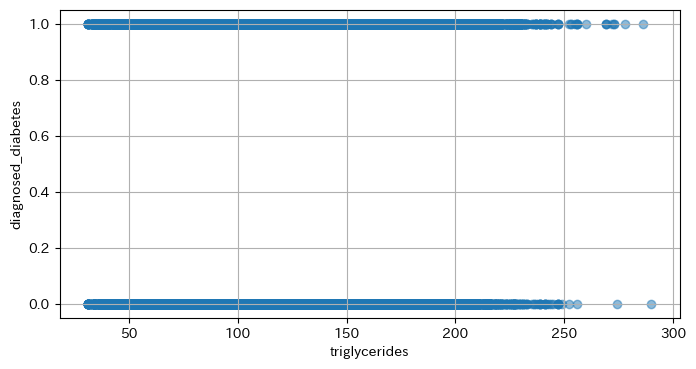

In [20]:
plt.figure(figsize=(8, 4))
plt.scatter(train["triglycerides"], train[target_col], alpha=0.5)
plt.xlabel("triglycerides")
plt.ylabel(target_col)
plt.grid()
plt.show()

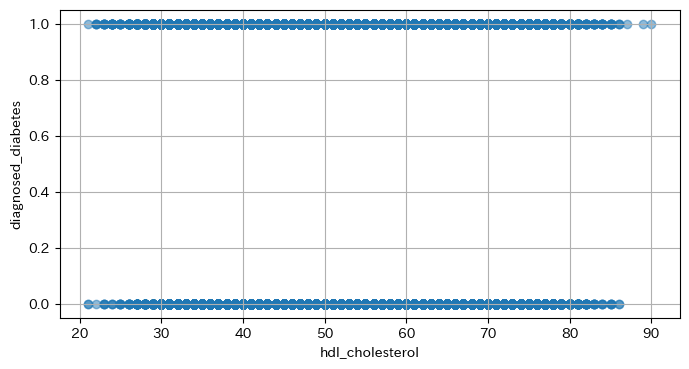

In [21]:
plt.figure(figsize=(8, 4))
plt.scatter(train["hdl_cholesterol"], train[target_col], alpha=0.5)
plt.xlabel("hdl_cholesterol")
plt.ylabel(target_col)
plt.grid()
plt.show()

In [22]:
def plot_categorycal_boxplots(data, cat_cols, target_col):
    for col in cat_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=col, y=target_col, data=data)
        plt.title(f"{col} vs {target_col}")
        plt.grid()
        plt.show()

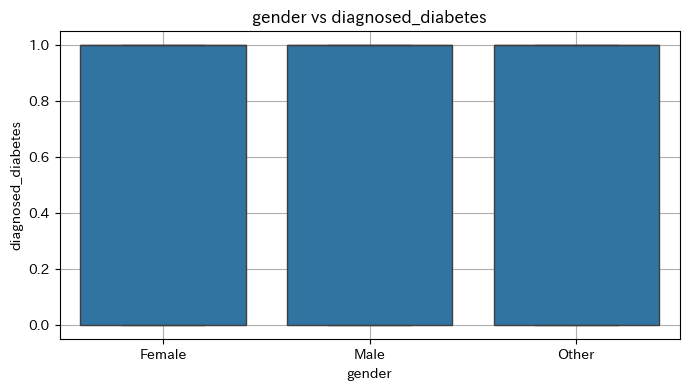

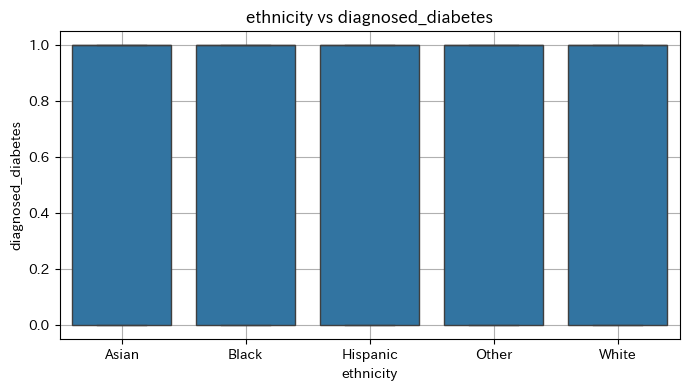

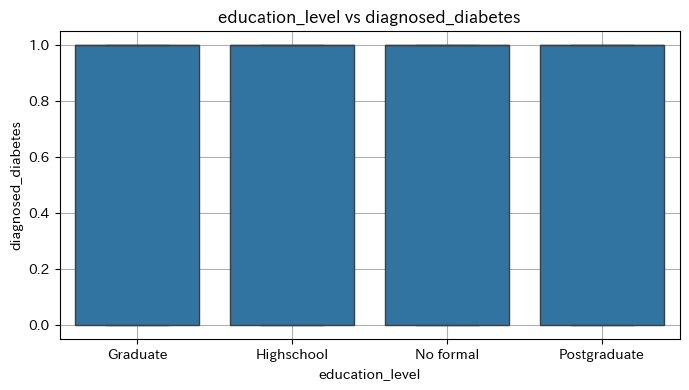

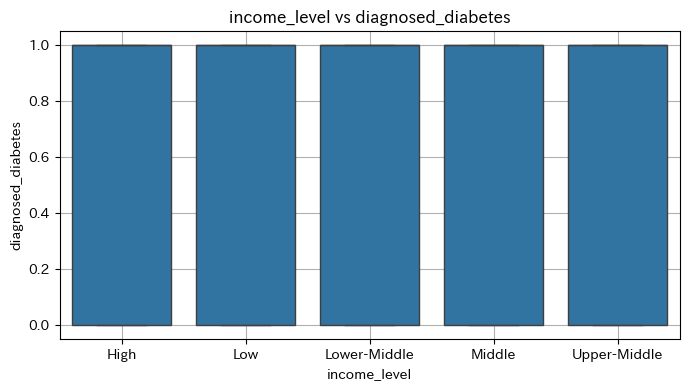

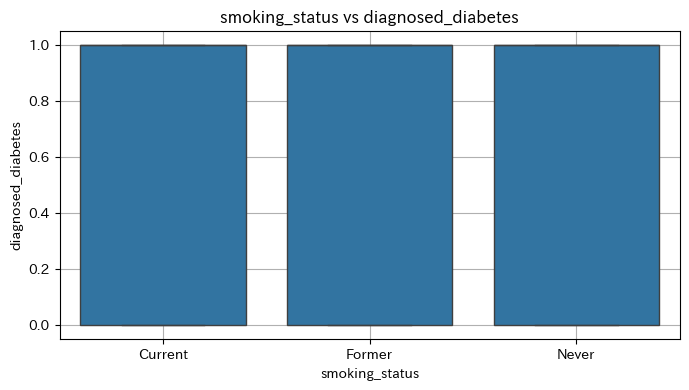

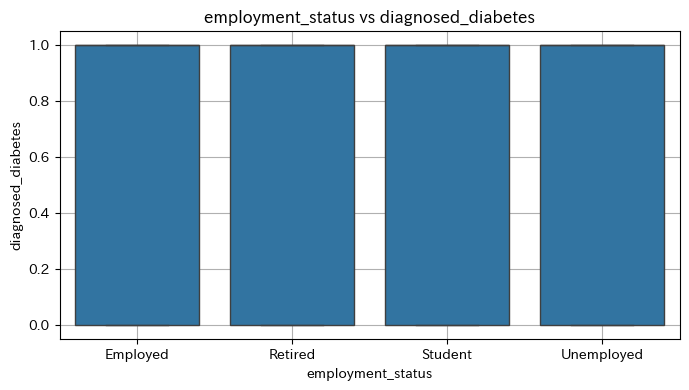

In [23]:
plot_categorycal_boxplots(train, cat_features, target_col)

In [24]:
def cross_tab_print(df: pd.DataFrame, row_col: str, col_col: str, normalize: bool = True):
    """
    df        : pandas.DataFrame
    row_col   : 行方向に使うカラム名
    col_col   : 列方向に使うカラム名
    normalize : True のとき行方向で割合も表示する
    """
    # 件数ベース
    ct_count = pd.crosstab(df[row_col], df[col_col])
    print("=== count ===")
    print(ct_count)

    if normalize:
        ct_ratio = pd.crosstab(
            df[row_col],
            df[col_col],
            normalize="index"
        )
        print("\n=== ratio (row-normalized) ===")
        print(ct_ratio.round(3))

In [31]:
# 件数＋割合を表示
cross_tab_print(train, "gender", "ethnicity")
cross_tab_print(train, "gender", "education_level")
# cross_tab_print(train, "gender", "income_level")
# cross_tab_print(train, "gender", "smoking_status")
# cross_tab_print(train, "gender", "employment_status")
# 件数だけ表示したいとき
# cross_tab_print(df, "lighting", "weather", normalize=False)

=== count ===
ethnicity  Asian  Black  Hispanic  Other   White
gender                                          
Female     31090  54886     67657   9141  200463
Male       28713  50826     61677   8199  183670
Other        317    589       650    102    2020

=== ratio (row-normalized) ===
ethnicity  Asian  Black  Hispanic  Other  White
gender                                         
Female     0.086  0.151     0.186  0.025  0.552
Male       0.086  0.153     0.185  0.025  0.551
Other      0.086  0.160     0.177  0.028  0.549
=== count ===
education_level  Graduate  Highschool  No formal  Postgraduate
gender                                                        
Female             136054      178169       7676         41338
Male               123862      164091       7190         37942
Other                1352        1885         79           362

=== ratio (row-normalized) ===
education_level  Graduate  Highschool  No formal  Postgraduate
gender                                       

In [39]:
cross_tab_print(train, "smoking_status", "education_level")
cross_tab_print(train, "smoking_status", "income_level")

=== count ===
education_level  Graduate  Highschool  No formal  Postgraduate
smoking_status                                                
Current             38780       50384       2317         11882
Former              38167       50431       2153         11438
Never              184321      243330      10475         56322

=== ratio (row-normalized) ===
education_level  Graduate  Highschool  No formal  Postgraduate
smoking_status                                                
Current             0.375       0.487      0.022         0.115
Former              0.373       0.494      0.021         0.112
Never               0.373       0.492      0.021         0.114
=== count ===
income_level     High    Low  Lower-Middle  Middle  Upper-Middle
smoking_status                                                  
Current          2489  12748         26265   43141         18720
Former           2478  12514         25843   42183         19171
Never           12267  60541        126462  205233

In [ ]:
# 件数＋割合を表示
cross_tab_print(train, "gender", "income_level")
cross_tab_print(train, "gender", "smoking_status")

# 件数だけ表示したいとき
# cross_tab_print(df, "lighting", "weather", normalize=False)

=== count ===
income_level  High    Low  Lower-Middle  Middle  Upper-Middle
gender                                                       
Female        9066  44460         92814  150733         66164
Male          8067  40916         84845  138229         61028
Other          101    427           911    1595           644

=== ratio (row-normalized) ===
income_level   High    Low  Lower-Middle  Middle  Upper-Middle
gender                                                        
Female        0.025  0.122         0.256   0.415         0.182
Male          0.024  0.123         0.255   0.415         0.183
Other         0.027  0.116         0.248   0.434         0.175
=== count ===
smoking_status  Current  Former   Never
gender                                 
Female            53615   52196  257426
Male              49178   49472  234435
Other               570     521    2587

=== ratio (row-normalized) ===
smoking_status  Current  Former  Never
gender                                
Femal

In [33]:
# 件数＋割合を表示
cross_tab_print(train, "gender", "employment_status")
cross_tab_print(train, "ethnicity", "employment_status")

# 件数だけ表示したいとき
# cross_tab_print(df, "lighting", "weather", normalize=False)

=== count ===
employment_status  Employed  Retired  Student  Unemployed
gender                                                   
Female               267794    60109     9507       25827
Male                 245655    55019     8684       23727
Other                  2721      607      117         233

=== ratio (row-normalized) ===
employment_status  Employed  Retired  Student  Unemployed
gender                                                   
Female                0.737    0.165    0.026       0.071
Male                  0.738    0.165    0.026       0.071
Other                 0.740    0.165    0.032       0.063
=== count ===
employment_status  Employed  Retired  Student  Unemployed
ethnicity                                                
Asian                 44223     9941     1609        4347
Black                 78442    17490     2802        7567
Hispanic              95746    21576     3380        9282
Other                 12854     2887      486        1215
White       

In [34]:
cross_tab_print(train, "ethnicity", "education_level")
cross_tab_print(train, "ethnicity", "income_level")

=== count ===
education_level  Graduate  Highschool  No formal  Postgraduate
ethnicity                                                     
Asian               22144       29850       1329          6797
Black               40229       51545       2262         12265
Hispanic            48468       63827       2709         14980
Other                6771        8403        387          1881
White              143656      190520       8258         43719

=== ratio (row-normalized) ===
education_level  Graduate  Highschool  No formal  Postgraduate
ethnicity                                                     
Asian               0.368       0.497      0.022         0.113
Black               0.378       0.485      0.021         0.115
Hispanic            0.373       0.491      0.021         0.115
Other               0.388       0.482      0.022         0.108
White               0.372       0.493      0.021         0.113
=== count ===
income_level  High    Low  Lower-Middle  Middle  Upper-Mid

In [ ]:
cross_tab_print(train, "ethnicity", "smoking_status")
cross_tab_print(train, "education_level", "employment_status")

=== count ===
smoking_status  Current  Former   Never
ethnicity                              
Asian              8901    8719   42500
Black             15688   15637   74976
Hispanic          19741   18980   91263
Other              2574    2580   12288
White             56459   56273  273421

=== ratio (row-normalized) ===
smoking_status  Current  Former  Never
ethnicity                             
Asian             0.148   0.145  0.707
Black             0.148   0.147  0.705
Hispanic          0.152   0.146  0.702
Other             0.148   0.148  0.705
White             0.146   0.146  0.708
=== count ===
employment_status  Employed  Retired  Student  Unemployed
education_level                                          
Graduate             192779    43248     6711       18530
Highschool           253237    57079     9141       24688
No formal             11162     2409      382         992
Postgraduate          58992    12999     2074        5577

=== ratio (row-normalized) ===
employm

In [36]:
cross_tab_print(train, "education_level", "income_level")
cross_tab_print(train, "education_level", "smoking_status")

=== count ===
income_level     High    Low  Lower-Middle  Middle  Upper-Middle
education_level                                                 
Graduate         6360  31174         67282  108125         48327
Highschool       8448  42826         87700  142680         62491
No formal         393   1801          3745    6130          2876
Postgraduate     2033  10002         19843   33622         14142

=== ratio (row-normalized) ===
income_level      High    Low  Lower-Middle  Middle  Upper-Middle
education_level                                                  
Graduate         0.024  0.119         0.258   0.414         0.185
Highschool       0.025  0.124         0.255   0.415         0.182
No formal        0.026  0.121         0.251   0.410         0.192
Postgraduate     0.026  0.126         0.249   0.422         0.178
=== count ===
smoking_status   Current  Former   Never
education_level                         
Graduate           38780   38167  184321
Highschool         50384   5043

In [37]:
cross_tab_print(train, "income_level", "employment_status")
cross_tab_print(train, "income_level", "education_level")

=== count ===
employment_status  Employed  Retired  Student  Unemployed
income_level                                             
High                  12735     2863      416        1220
Low                   62905    14261     2192        6445
Lower-Middle         132018    29477     4631       12444
Middle               214594    47595     7814       20554
Upper-Middle          93918    21539     3255        9124

=== ratio (row-normalized) ===
employment_status  Employed  Retired  Student  Unemployed
income_level                                             
High                  0.739    0.166    0.024       0.071
Low                   0.733    0.166    0.026       0.075
Lower-Middle          0.739    0.165    0.026       0.070
Middle                0.739    0.164    0.027       0.071
Upper-Middle          0.735    0.168    0.025       0.071
=== count ===
education_level  Graduate  Highschool  No formal  Postgraduate
income_level                                                  
Hi

In [38]:
cross_tab_print(train, "income_level", "smoking_status")
cross_tab_print(train, "smoking_status", "employment_status")

=== count ===
smoking_status  Current  Former   Never
income_level                           
High               2489    2478   12267
Low               12748   12514   60541
Lower-Middle      26265   25843  126462
Middle            43141   42183  205233
Upper-Middle      18720   19171   89945

=== ratio (row-normalized) ===
smoking_status  Current  Former  Never
income_level                          
High              0.144   0.144  0.712
Low               0.149   0.146  0.706
Lower-Middle      0.147   0.145  0.708
Middle            0.148   0.145  0.706
Upper-Middle      0.146   0.150  0.704
=== count ===
employment_status  Employed  Retired  Student  Unemployed
smoking_status                                           
Current               75973    17259     2733        7398
Former                76031    16398     2567        7193
Never                364166    82078    13008       35196

=== ratio (row-normalized) ===
employment_status  Employed  Retired  Student  Unemployed
smoking

In [41]:
for col in ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']:
    print(f"\n=== {col} ===")
    print(train.groupby(col)['diagnosed_diabetes'].mean().sort_values(ascending=False))


=== gender ===
gender
Other     0.640566
Male      0.624294
Female    0.622205
Name: diagnosed_diabetes, dtype: float32

=== ethnicity ===
ethnicity
Other       0.635936
Asian       0.628493
White       0.624105
Black       0.623879
Hispanic    0.616314
Name: diagnosed_diabetes, dtype: float32

=== education_level ===
education_level
No formal       0.636066
Graduate        0.627008
Highschool      0.621462
Postgraduate    0.616647
Name: diagnosed_diabetes, dtype: float32

=== income_level ===
income_level
Low             0.630328
Lower-Middle    0.626835
High            0.623593
Upper-Middle    0.620420
Middle          0.620291
Name: diagnosed_diabetes, dtype: float32

=== smoking_status ===
smoking_status
Former     0.625332
Current    0.623124
Never      0.622911
Name: diagnosed_diabetes, dtype: float32

=== employment_status ===
employment_status
Employed      0.624643
Unemployed    0.622130
Student       0.621586
Retired       0.618059
Name: diagnosed_diabetes, dtype: float32
